In [73]:
import sqlite3
import pandas as pd
from pathlib import Path

DB_PATH = Path("data/armor.db")

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("SELECT * FROM armor", conn)

df.head()

,id,name,equip_slot,map_link,source_1,source_2,repurchase_shop,buy_price_rupees,buy_price_poes,sell_price_base,...,upgrade_material_qty_starstarstarstar_1,upgrade_material_starstarstarstar_2,upgrade_material_qty_starstarstarstar_2,upgrade_material_starstarstarstar_3,upgrade_material_qty_starstarstarstar_3,acquisition_category,defense_max,resale_ratio,defense_per_rupee,max_defense_per_rupee
0,1,Archaic Tunic,Body,Archaic Tunic,Treasure Chest (Great Sky Island),NaN,Cece (Ventest Clothing Boutique),50.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,shop,NaN,0.300000,0.020000,NaN
1,2,Archaic Legwear,Legs,Archaic Legwear,Treasure Chest (Great Sky Island),NaN,Cece (Ventest Clothing Boutique),50.0,NaN,15.0,...,NaN,NaN,NaN,NaN,NaN,shop,NaN,0.300000,0.020000,NaN
2,3,Archaic Warm Greaves,Legs,Archaic Warm Greaves,Treasure Chest (Great Sky Island),NaN,Cece (Ventest Clothing Boutique),80.0,NaN,20.0,...,NaN,NaN,NaN,NaN,NaN,shop,NaN,0.250000,0.025000,NaN
3,4,Hylian Hood,Head,Hylian Hood,Armor Shop (Lookout Landing),Armor Shop (Ventest Clothing Boutique),NaN,70.0,NaN,15.0,...,5.0,Bokoblin Guts,5.0,Amber,30.0,shop,20.0,0.214286,0.042857,0.285714
4,5,Hylian Tunic,Body,Hylian Tunic,Armor Shop (Lookout Landing),Armor Shop (Ventest Clothing Boutique),NaN,130.0,NaN,35.0,...,5.0,Bokoblin Guts,5.0,Amber,30.0,shop,20.0,0.269231,0.023077,0.153846


In [74]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 135 entries, 0 to 134
Data columns (total 53 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   id                                       135 non-null    int64  
 1   name                                     135 non-null    str    
 2   equip_slot                               135 non-null    str    
 3   map_link                                 125 non-null    str    
 4   source_1                                 135 non-null    str    
 5   source_2                                 30 non-null     str    
 6   repurchase_shop                          96 non-null     str    
 7   buy_price_rupees                         79 non-null     float64
 8   buy_price_poes                           47 non-null     float64
 9   sell_price_base                          125 non-null    float64
 10  sell_price_1                             94 non-null     floa

In [75]:
df.columns

Index(['id', 'name', 'equip_slot', 'map_link', 'source_1', 'source_2',
       'repurchase_shop', 'buy_price_rupees', 'buy_price_poes',
       'sell_price_base', 'sell_price_1', 'sell_price_2', 'sell_price_3',
       'sell_price_4', 'effect', 'hidden_effect', 'set_bonus',
       'hidden_set_bonus', 'dyeable', 'defense_base', 'defense_1', 'defense_2',
       'defense_3', 'defense_4', 'upgrade_material_star_1',
       'upgrade_material_qty_star_1', 'upgrade_material_star_2',
       'upgrade_material_qty_star_2', 'upgrade_material_star_3',
       'upgrade_material_qty_star_3', 'upgrade_material_starstar_1',
       'upgrade_material_qty_starstar_1', 'upgrade_material_starstar_2',
       'upgrade_material_qty_starstar_2', 'upgrade_material_starstar_3',
       'upgrade_material_qty_starstar_3', 'upgrade_material_starstarstar_1',
       'upgrade_material_qty_starstarstar_1',
       'upgrade_material_starstarstar_2',
       'upgrade_material_qty_starstarstar_2',
       'upgrade_material_starsta

# 🗺️ Dataset Landscape Overview

Before we get to the optimization and ranking, I want to understand the world we’re working with.

Like any proper Zelda adventure, you don’t just run straight into the final boss. You explore the map first. You figure out what tools are available. You understand the terrain.

So before deciding what armor is “worth it,” we need to look at the dataset itself and answer a few foundational questions:

1. What types of armor exist (Hylian Set, Soldier’s Set, etc.)?
2. How many items are there per equip slot?
3. What effects are represented?
4. How is defense distributed (base vs. max)?
5. What does the price distribution look like?
6. Which items are the most expensive?
7. Where do items primarily come from?

Once we understand the landscape, we can move into value analysis and progression strategy with intention instead of assumptions.

In [76]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


# Armor by Equip Count

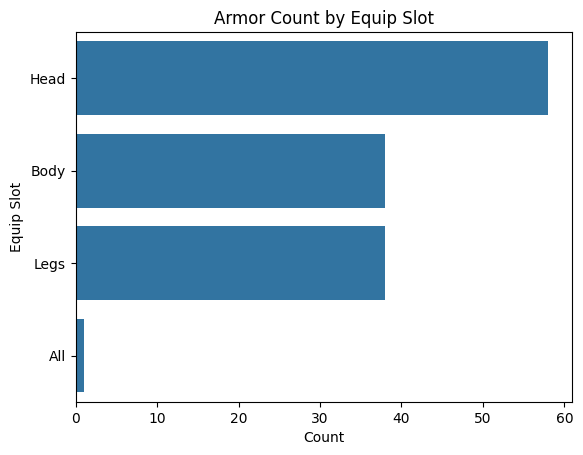

,equip_slot,count
0,Head,58
1,Body,38
2,Legs,38
3,All,1


In [77]:
import matplotlib.pyplot as plt
import seaborn as sns 

slot_counts = (
    df.groupby("equip_slot")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="count")
)

plt.figure()
sns.barplot(data=slot_counts, x="count", y="equip_slot")
plt.title("Armor Count by Equip Slot")
plt.xlabel("Count")
plt.ylabel("Equip Slot")
plt.show()

slot_counts

In [78]:
df[df['equip_slot'] == 'All']

,id,name,equip_slot,map_link,source_1,source_2,repurchase_shop,buy_price_rupees,buy_price_poes,sell_price_base,...,upgrade_material_qty_starstarstarstar_1,upgrade_material_starstarstarstar_2,upgrade_material_qty_starstarstarstar_2,upgrade_material_starstarstarstar_3,upgrade_material_qty_starstarstarstar_3,acquisition_category,defense_max,resale_ratio,defense_per_rupee,max_defense_per_rupee
134,135,Ancient Hero's Aspect,All,Ancient Hero's Aspect,"Treasure Chest (Temple of Time, Complete All 1...",NaN,NaN,NaN,NaN,NaN,...,9.0,Silver Lynel Mace Horn,9.0,Gleeok Guts,9.0,chest,84.0,NaN,NaN,NaN


Observations:
1. The Ancient Hero's Aspect armor is categorized as "All" under equip_slot.
This indicates a full-body armor piece that occupies all slots simultaneously (head/body/legs).
2. The dataset shows that a large portion of armor pieces are headgear. This may indicate a design emphasis on head protection within the game. From a gameplay perspective, this could suggest that headgear plays a particularly important defensive role.

# Armor Set Bonus

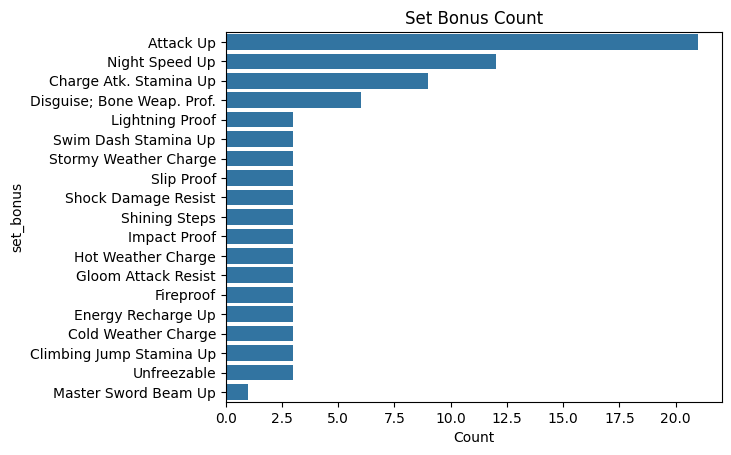

,set_bonus,count
0,Attack Up,21
1,Night Speed Up,12
2,Charge Atk. Stamina Up,9
3,Disguise; Bone Weap. Prof.,6
4,Lightning Proof,3
5,Swim Dash Stamina Up,3
6,Stormy Weather Charge,3
7,Slip Proof,3
8,Shock Damage Resist,3
9,Shining Steps,3


In [79]:
set_counts = (
    df.groupby("set_bonus")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="count")
)

plt.figure()
sns.barplot(data=set_counts, x="count", y="set_bonus")
plt.title("Set Bonus Count")
plt.xlabel("Count")
plt.ylabel("set_bonus")
plt.show()

set_counts.head(15)

In [80]:
df["set_bonus"].isna().sum()

np.int64(44)

In [81]:
total_items = len(df)
null_bonus = df["set_bonus"].isna().sum()
non_null_bonus = total_items - null_bonus

total_items, null_bonus, non_null_bonus

(135, np.int64(44), np.int64(91))

In [82]:
44/135

0.32592592592592595

One-third of all armor has no set bonus. Set-based optimization, therefore, applies to only about 67% of the dataset.

# Armor Effects

In [83]:
# What functional types exist?

unique_effects = df["effect"].fillna("None").unique()
sorted(unique_effects)

['Attack Up',
 'Climb Speed Up',
 'Cold Resistance',
 'Cold Weather Attack',
 'Energy Up',
 'Flame Guard',
 'Gloom Resistance',
 'Glow',
 'Heat Resistance',
 'Hot Weather Attack',
 'Lightning Proof',
 'None',
 'Rupee Padding',
 'Sand Speed Up',
 'Shock Resistance',
 'Skydive Mobility Up',
 'Slip Resistance',
 'Snow Speed Up',
 'Stealth Up',
 'Stormy Weather Attack',
 'Swim Speed Up',
 'Unfreezable']

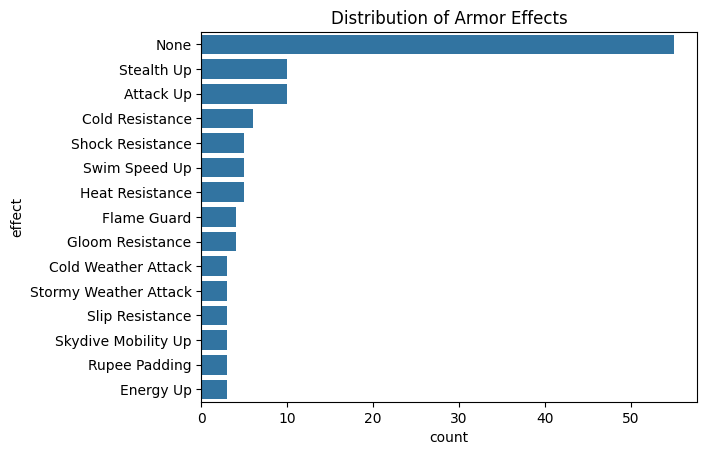

In [84]:
effect_counts = (
    df.assign(effect=df["effect"].fillna("None"))
      .groupby("effect")
      .size()
      .sort_values(ascending=False)
      .reset_index(name="count")
)

plt.figure()
sns.barplot(data=effect_counts.head(15), x="count", y="effect")
plt.title("Distribution of Armor Effects")
plt.show()

In [85]:
total_armor = len(df)
null_effect = df["effect"].isna().sum()
non_null_effect = total_items - null_bonus

total_armor, null_effect, non_null_effect

(135, np.int64(55), np.int64(91))

In [86]:
55/135

0.4074074074074074

In [87]:
df["has_effect"] = df["effect"].notna()
df["has_set_bonus"] = df["set_bonus"].notna()

df[["has_effect", "has_set_bonus"]].value_counts()

has_effect  has_set_bonus
True        True             57
False       True             34
True        False            23
False       False            21
Name: count, dtype: int64

In [88]:
df["defense_base"].isna().sum()

np.int64(0)

In [89]:
df["defense_max"].isna().sum()

np.int64(32)

In [90]:
df["defense_base"].dtype

dtype('int64')

In [91]:
df["defense_base"].min(), df["defense_base"].max()

(np.int64(0), np.int64(12))

Every row has a defense value recorded, but some armor has 0 defense, meaning a portion of items provide no protective benefit.

In [92]:
(df["defense_base"] == 0).sum()

np.int64(1)

In [93]:
zero_def = df[df["defense_base"] == 0][
    ["name", "equip_slot", "effect", "set_bonus", "acquisition_category", "buy_price_rupees"]
].sort_values("buy_price_rupees", ascending=False)

zero_def

,name,equip_slot,effect,set_bonus,acquisition_category,buy_price_rupees
79,Well-Worn Hair Band,Head,NaN,NaN,shop,20.0


Defense is a foundational attribute in the dataset. This means 134/135 have some defensive value, since one item offers zero protection. It is safe to suggest the game is a mix of defensive, utility, and cosmetic design.

# Armor Defense (Base and Max)

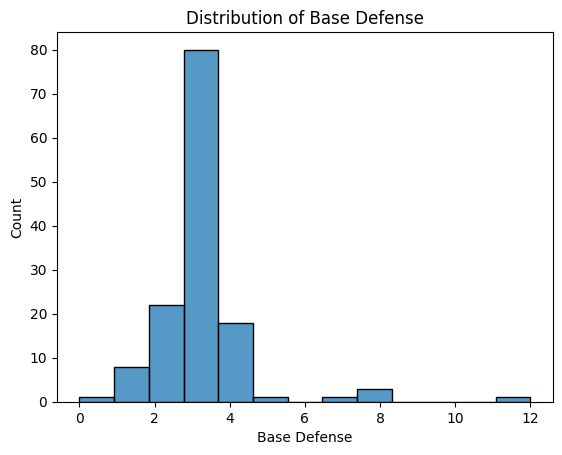

In [94]:
plt.figure()
sns.histplot(df["defense_base"], bins=13)
plt.title("Distribution of Base Defense")
plt.xlabel("Base Defense")
plt.ylabel("Count")
plt.show()

Most items cluster between 2-4 base defense.

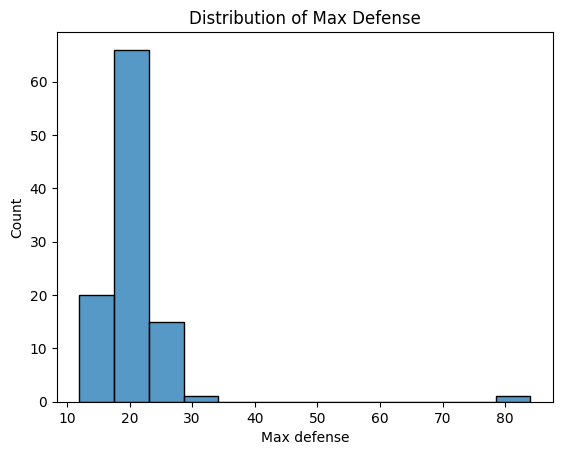

In [95]:
plt.figure()
sns.histplot(df["defense_max"], bins=13)
plt.title("Distribution of Max Defense")
plt.xlabel("Max defense")
plt.ylabel("Count")
plt.show()

In [96]:
Most items cluster between 15-25 max defense. 

SyntaxError: invalid syntax (1645958438.py, line 1)

In [97]:
df["defense_max"].max()

np.float64(84.0)

In [98]:
df[df["defense_max"] == 84]

,id,name,equip_slot,map_link,source_1,source_2,repurchase_shop,buy_price_rupees,buy_price_poes,sell_price_base,...,upgrade_material_qty_starstarstarstar_2,upgrade_material_starstarstarstar_3,upgrade_material_qty_starstarstarstar_3,acquisition_category,defense_max,resale_ratio,defense_per_rupee,max_defense_per_rupee,has_effect,has_set_bonus
134,135,Ancient Hero's Aspect,All,Ancient Hero's Aspect,"Treasure Chest (Temple of Time, Complete All 1...",NaN,NaN,NaN,NaN,NaN,...,9.0,Gleeok Guts,9.0,chest,84.0,NaN,NaN,NaN,False,True


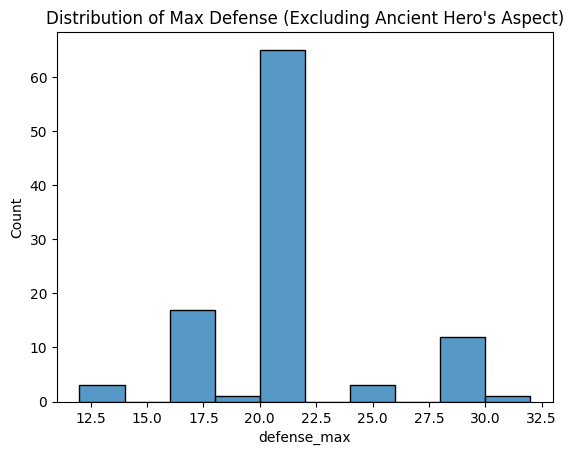

In [99]:
# Let's remove the outlier to get a normal distribution

df_no_outlier = df[df["defense_max"] < 80]

sns.histplot(df_no_outlier["defense_max"], bins=10)
plt.title("Distribution of Max Defense (Excluding Ancient Hero's Aspect)")
plt.show()

In [100]:
df_no_outlier["defense_max"].describe()

count    102.000000
mean      20.254902
std        3.751399
min       12.000000
25%       20.000000
50%       20.000000
75%       20.000000
max       32.000000
Name: defense_max, dtype: float64

Observations:
1. Most armor maxes out between 16–24 
2. A smaller cluster reaches 28–32
3. Very few exceed 30

We can infer that defense alone won’t drastically change survivability. Effects, bonuses, and special abilities will likely have a greater impact on advancements. 

# Effects Analysis Continued

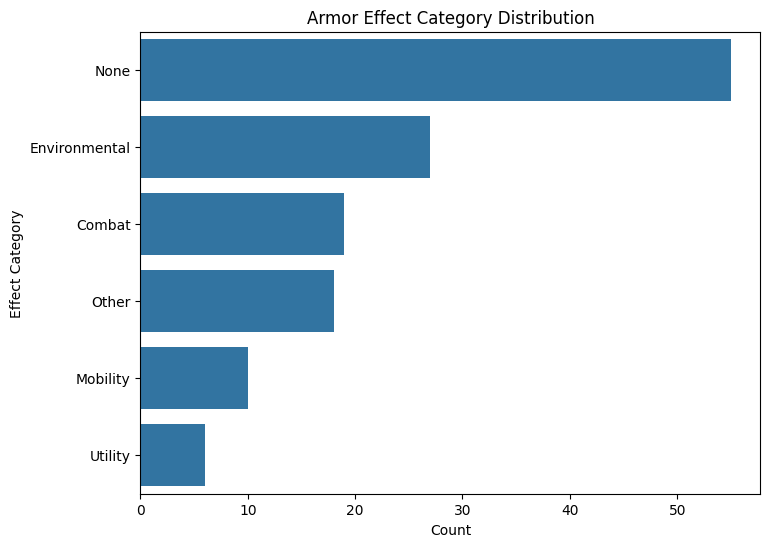

effect_category
None             55
Environmental    27
Combat           19
Other            18
Mobility         10
Utility           6
Name: count, dtype: int64

In [101]:
# Let's categorize the different effects to understand what these effects are actually doing for Link. 

def categorize_effect(effect):
    if pd.isna(effect):
        return "None"
    elif "Resistance" in effect or "Guard" in effect:
        return "Environmental"
    elif "Attack" in effect:
        return "Combat"
    elif "Speed" in effect or "Climb" in effect or "Swim" in effect:
        return "Mobility"
    elif "Rupee" in effect or "Energy" in effect:
        return "Utility"
    else:
        return "Other"

df["effect_category"] = df["effect"].apply(categorize_effect)

effect_cat_counts = (
    df["effect_category"]
    .value_counts()
    .reset_index()
)

effect_cat_counts.columns = ["effect_category", "count"]

plt.figure(figsize=(8,6))
sns.barplot(data=effect_cat_counts, x="count", y="effect_category")
plt.title("Armor Effect Category Distribution")
plt.xlabel("Count")
plt.ylabel("Effect Category")
plt.show()

df["effect_category"].value_counts()

In [102]:
# 18 fall into the other category. Let's explore what "other" might imply 

df[df["effect_category"] == "Other"]["effect"].value_counts()

effect
Stealth Up             10
Skydive Mobility Up     3
Glow                    3
Lightning Proof         1
Unfreezable             1
Name: count, dtype: int64

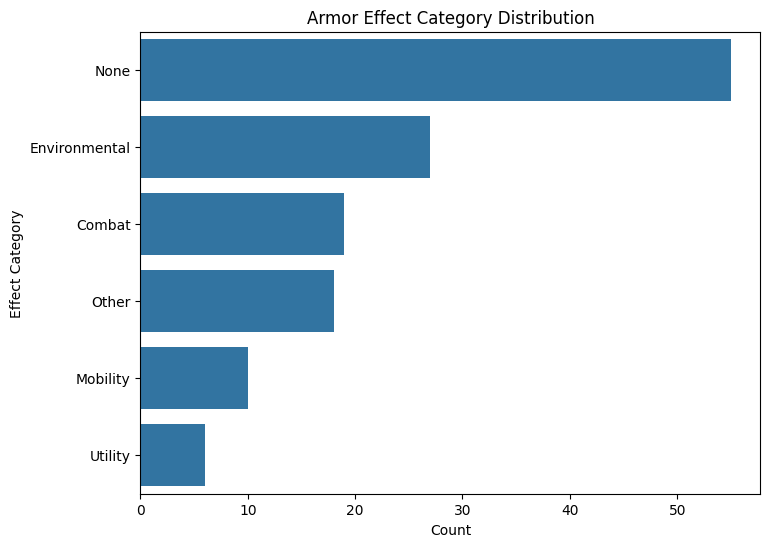

effect_category
None             55
Environmental    29
Combat           19
Mobility         13
Tactical         10
Utility           9
Name: count, dtype: int64

In [103]:
# We need to recategorize 

def categorize_effect(effect):
    if pd.isna(effect):
        return "None"
    
    # Environmental survival
    elif any(keyword in effect for keyword in [
        "Resistance", "Guard", "Unfreezable", "Lightning Proof", "Gloom"
    ]):
        return "Environmental"
    
    # Combat
    elif "Attack" in effect:
        return "Combat"
    
    # Mobility
    elif any(keyword in effect for keyword in [
        "Speed", "Climb", "Swim", "Skydive"
    ]):
        return "Mobility"
    
    # Tactical
    elif "Stealth" in effect:
        return "Tactical"
    
    # Utility
    elif any(keyword in effect for keyword in [
        "Rupee", "Energy", "Glow"
    ]):
        return "Utility"
    
    else:
        return "Other"


plt.figure(figsize=(8,6))
sns.barplot(data=effect_cat_counts, x="count", y="effect_category")
plt.title("Armor Effect Category Distribution")
plt.xlabel("Count")
plt.ylabel("Effect Category")
plt.show()

df["effect_category"] = df["effect"].apply(categorize_effect)
df["effect_category"].value_counts()

In [104]:
df.groupby("effect_category")["defense_max"].mean().sort_values()

effect_category
Tactical         14.285714
Mobility         18.769231
Combat           19.000000
Environmental    19.416667
Utility          24.000000
None             24.108108
Name: defense_max, dtype: float64

Utility and “None” have the highest max defense. That suggests that many no-effect armor pieces are actually high-defense traditional armor.

In [105]:
df.groupby("effect_category")["buy_price_rupees"].mean().sort_values()

effect_category
None             1730.454545
Mobility         2130.000000
Environmental    2174.090909
Tactical         2300.000000
Combat           3840.000000
Utility          4000.000000
Name: buy_price_rupees, dtype: float64

Observations:
1. Combat and Utility are dramatically more expensive. But their defense is not dramatically higher.
2. Utility pieces may be expensive and late-game oriented.
3. Environmental gear gives nearly identical survivability at almost half the cost.

In [106]:
df.groupby("effect_category")["max_defense_per_rupee"].mean().sort_values()

effect_category
Combat           0.005067
Utility          0.006000
Tactical         0.015087
Environmental    0.015598
Mobility         0.016353
None             0.090899
Name: max_defense_per_rupee, dtype: float64

# The Big Insight

The armor ecosystem appears to be structured like this:

Cheap defensive gear (None) → highest survivability efficiency

Environmental & mobility → balanced utility + reasonable cost

Combat & utility → expensive, low survivability efficiency

In [107]:
df.sort_values("max_defense_per_rupee", ascending=False)[
    ["name", "effect_category", "buy_price_rupees", "defense_max", "max_defense_per_rupee"]
].head(15)

,name,effect_category,buy_price_rupees,defense_max,max_defense_per_rupee
3,Hylian Hood,None,70.0,20.0,0.285714
5,Hylian Trousers,None,120.0,20.0,0.166667
6,Soldier's Helm,None,180.0,28.0,0.155556
4,Hylian Tunic,None,130.0,20.0,0.153846
8,Soldier's Greaves,None,200.0,28.0,0.140000
7,Soldier's Armor,None,250.0,28.0,0.112000
78,Amber Earrings,None,400.0,28.0,0.070000
18,Desert Voe Headband,Environmental,450.0,20.0,0.044444
10,Snowquill Tunic,Environmental,500.0,20.0,0.040000
29,Climbing Boots,Mobility,600.0,20.0,0.033333


# Acquisition Category

In [108]:
df.groupby("acquisition_category")["max_defense_per_rupee"].mean().sort_values()

acquisition_category
chest    0.010909
shop     0.028293
other         NaN
Name: max_defense_per_rupee, dtype: float64

Observation:
On average, armor purchased from shops provides more defense per rupee than armor found in chests. 

In [109]:
df.groupby("acquisition_category")["max_defense_per_rupee"].count()

acquisition_category
chest     1
other     0
shop     65
Name: max_defense_per_rupee, dtype: int64

In [110]:
df[df["acquisition_category"] == "chest"]

,id,name,equip_slot,map_link,source_1,source_2,repurchase_shop,buy_price_rupees,buy_price_poes,sell_price_base,...,upgrade_material_starstarstarstar_3,upgrade_material_qty_starstarstarstar_3,acquisition_category,defense_max,resale_ratio,defense_per_rupee,max_defense_per_rupee,has_effect,has_set_bonus,effect_category
15,16,Zora Helm,Head,Zora Helm,Treasure Chest (Floating Scales Island),NaN,NaN,NaN,NaN,NaN,...,Opal,20.0,chest,20.0,NaN,NaN,NaN,True,True,Mobility
17,18,Zora Greaves,Legs,Zora Greaves,Treasure Chest (Ancient Zora Waterworks),NaN,NaN,NaN,NaN,NaN,...,Opal,20.0,chest,20.0,NaN,NaN,NaN,True,True,Mobility
37,38,Royal Guard Uniform,Body,Royal Guard Uniform,Treasure Chest (Guard’s Chamber),Armor Shop (Ventest Clothing Boutique),NaN,2200.0,NaN,550.0,...,Gleeok Guts,3.0,chest,24.0,0.25,0.001818,0.010909,False,True,None
57,58,Charged Headdress,Head,Charged Headdress,Treasure Chest (Dracozu River),NaN,NaN,NaN,NaN,NaN,...,Large Zonai Charge,5.0,chest,20.0,NaN,NaN,NaN,True,True,Combat
58,59,Charged Shirt,Body,Charged Shirt,Treasure Chest (Dracozu River),NaN,NaN,NaN,NaN,NaN,...,Large Zonai Charge,5.0,chest,20.0,NaN,NaN,NaN,True,True,Combat
59,60,Charged Trousers,Legs,Charged Trousers,Treasure Chest (Dracozu River),NaN,NaN,NaN,NaN,NaN,...,Large Zonai Charge,5.0,chest,20.0,NaN,NaN,NaN,True,True,Combat
90,91,Champion's Leathers,Body,Champion's Leathers,Treasure Chest (Hyrule Castle),NaN,NaN,NaN,NaN,NaN,...,Sundelion,20.0,chest,32.0,NaN,NaN,NaN,False,False,None
134,135,Ancient Hero's Aspect,All,Ancient Hero's Aspect,"Treasure Chest (Temple of Time, Complete All 1...",NaN,NaN,NaN,NaN,NaN,...,Gleeok Guts,9.0,chest,84.0,NaN,NaN,NaN,False,True,None


The chest “average” is only being driven by one value. It is worth noting that we can not accurately compare it to the shop category.

In [111]:
df.groupby("acquisition_category")["max_defense_per_rupee"].agg(["count", "mean"])

,count,mean
acquisition_category,,
chest,1,0.010909
other,0,NaN
shop,65,0.028293


In [112]:
df.groupby("acquisition_category")["defense_max"].mean().sort_values()

acquisition_category
other    20.000000
shop     20.106383
chest    30.000000
Name: defense_max, dtype: float64

In [113]:
df.groupby("acquisition_category")["buy_price_rupees"].mean().sort_values()

acquisition_category
chest    2200.000000
shop     2476.923077
other            NaN
Name: buy_price_rupees, dtype: float64

In [114]:
df.groupby("acquisition_category")["sell_price_base"].mean().sort_values()

acquisition_category
shop     476.733871
chest    550.000000
other           NaN
Name: sell_price_base, dtype: float64

In [116]:
df.sort_values("max_defense_per_rupee", ascending=False)[
    ["name","defense_max","buy_price_rupees","max_defense_per_rupee"]
].head(10)

,name,defense_max,buy_price_rupees,max_defense_per_rupee
3,Hylian Hood,20.0,70.0,0.285714
5,Hylian Trousers,20.0,120.0,0.166667
6,Soldier's Helm,28.0,180.0,0.155556
4,Hylian Tunic,20.0,130.0,0.153846
8,Soldier's Greaves,28.0,200.0,0.140000
7,Soldier's Armor,28.0,250.0,0.112000
78,Amber Earrings,28.0,400.0,0.070000
18,Desert Voe Headband,20.0,450.0,0.044444
10,Snowquill Tunic,20.0,500.0,0.040000
29,Climbing Boots,20.0,600.0,0.033333


# Conclusion

The objective of this analysis was to determine which armor items in The Legend of Zelda: Tears of the Kingdom provide the greatest value for progressing through the main quests while minimizing time, effort, and in-game resources. To evaluate this, armor pieces were analyzed using factors such as defense value, acquisition method, and cost efficiency.

# Armor Importance Categories
### Essential Armor

Essential armor includes items required for progressing through specific environmental conditions encountered in the main quests. These pieces are necessary because they protect the player from environmental hazards such as extreme temperatures that would otherwise prevent progression.

### Optional but Helpful Armor

Some armor pieces are not strictly required for progression but provide meaningful advantages. These items improve survivability during combat or increase defensive strength. While players can progress without them, acquiring these items can make gameplay easier and more efficient.

### Primarily Cosmetic Armor

Certain armor pieces offer limited defensive or practical benefits relative to their cost. These items are typically acquired for aesthetic or completion purposes rather than gameplay optimization.

# Armor Ranking Criteria

Armor pieces were evaluated using the following factors:

### Main Quest Dependency
Armor required to progress through the main storyline or survive specific environments ranks highest.

### Environmental Necessity
Armor that protects against extreme temperatures or environmental hazards enables exploration of otherwise inaccessible regions.

### Combat Utility
Armor with higher defense values increases survivability during combat encounters.

### Cost Efficiency
Armor was also evaluated using the ratio of defense relative to cost in rupees. Items with higher defense per rupee provide better value.

# Best Performing Armor

### Most Cost-Efficient Armor

The Hylian Hood ranks as the most cost-efficient armor piece, providing the highest defense relative to its price. Because it is inexpensive and still offers solid defensive value, it is one of the best early-game armor investments for players trying to conserve rupees.

### Best Armor for Combat Protection

While the Hylian set offers strong cost efficiency, the Soldier’s set provides higher maximum defense and stronger protection during combat. Players prioritizing survivability may benefit from investing in Soldier’s set pieces once they have accumulated enough rupees.

### Environmental Armor

Armor such as the Snowquill Tunic and Desert Voe Headband rank lower in cost efficiency because their value comes from environmental resistance rather than defense alone. These items become essential when exploring regions with extreme temperatures.

# Most Efficient Acquisition Strategy

Based on the analysis, armor purchased from shops often provides a more reliable and efficient defense-to-cost ratio compared to armor obtained from chests.

A practical strategy for progressing through the game is:

Prioritize inexpensive armor early, such as the Hylian Hood and other Hylian set pieces, to quickly improve survivability.

Invest in stronger combat armor later, such as the Soldier’s set, for increased defense.

Acquire environmental armor when needed, such as Snowquill or Desert Voe items, to safely explore specific regions.

This approach balances cost efficiency, combat protection, and environmental survivability while minimizing unnecessary spending.

# Key findings based on this analysis:

Essential armor: Environmental armor needed to survive extreme regions.

Optional but helpful armor: High-defense armor such as the Soldier’s set that improves combat survivability.

Primarily cosmetic armor: Armor with limited gameplay benefit relative to cost.

Most cost-efficient armor: The Hylian Hood and other Hylian set pieces.

Most efficient acquisition strategy: Purchase affordable defensive armor early and obtain environmental armor only when required for exploration.

# Opportunities for Future Analysis

This analysis focused primarily on defense values and acquisition methods. Future work could expand on this by analyzing:

Armor upgrade paths and material requirements

Environmental resistance bonuses and special effects

Map locations and accessibility of armor pieces

Incorporating these additional factors would provide a more complete understanding of long-term armor value and player strategy.